In [8]:
import time
import random
import itertools
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

random.seed(12348)
np.random.seed(12348)

# Задание 1. Реализация Apriori
1. Напишите функцию apriori(transactions, min_support), которая:
- принимает список транзакций (каждая транзакция – множество или
список уникальных элементов);
- возвращает все частые наборы (frequent itemsets) в виде словаря {itemset_tuple: support_value}, где itemset_tuple – отсортированный
кортеж элементов.
- реализует этапы: генерация кандидатов (apriori_gen), подсчёт поддержки,
фильтрация по min_support.
2. Реализуйте функцию generate_rules(frequent_itemsets, min_confidence,
min_lift=1.0), которая для каждого частого набора длины ≥2 порождает
правила X→Y (где X – непустое собственное подмножество) и возвращает
список правил с метриками: (X, Y, support, confidence, lift, conviction, leverage).
3. Добавьте возможность отбора правил по максимальному числу элементов в
левой и правой части (например, max_antecedent_len=3, max_consequent_len=1)

In [ ]:
def apriori(transactions, min_support):

  n = len(transactions)
  min_count = min_support * n
  item_counts = collections.Counter()
  for t in transactions:
    item_counts.update(t)

  frequents = {tuple([item]): count / n for item, count in item_counts.items() if count >= min_count}

  k = 1
  # Отчюда начинается apriori_gen
  while True:
        k_itemsets = [list(k_set) for k_set in frequents.keys() if len(k_set) == k]
        if len(k_itemsets) < 2:
            break

        candidates = set()
        for i in range(len(k_itemsets)):
            for j in range(i + 1, len(k_itemsets)):
                candidate = tuple(sorted(set(k_itemsets[i] + k_itemsets[j])))
                if len(candidate) == k + 1:
                    candidates.add(candidate)

        valid_candidates = []
        for candidate in candidates:
            subsets = list(itertools.combinations(candidate, k))
            if all(sub in frequents for sub in subsets):
                valid_candidates.append(candidate)

        frequent = {}
        for candidate in valid_candidates:
            candidate_set = set(candidate)
            count = sum(1 for t in transactions if candidate_set.issubset(t))
            if count >= min_count:
                frequent[candidate] = count / n

        if not frequent:
            break

        frequents.update(frequent)
        k += 1

  return frequents


def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0,
                   max_antecedent_len=3, max_consequent_len=3,
                   buyer_sequences=None):
    rules = []
    n = None

    for itemset, supp_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        # Генерация всех непустых подмножеств для антецедента X
        for i in range(1, len(itemset)):
            for x in itertools.combinations(itemset, i):
                y = tuple(sorted(set(itemset) - set(x)))

                if len(x) > max_antecedent_len or len(y) > max_consequent_len:
                    continue

                supp_x = frequent_itemsets[x]
                supp_y = frequent_itemsets[y]

                conf = supp_xy / supp_x
                lift = conf / supp_y if supp_y > 0 else 0.0
                conv = (1 - supp_y) / (1 - conf) if conf != 1 else float('inf')
                lev = supp_xy - (supp_x * supp_y)

                """ Проверка порядка
                (мы решали на занятии с учётом хронологического времени покупки,
                но интернет говорит что это не правильно для apriori и FP-Growth
                поэтому при желании можно не передавать порядок покупки
                и тогда алгоритм не будет учитывать) """
                if buyer_sequences is not None:
                    if not _check_temporal_order(buyer_sequences, x, y):
                        continue

                if conf >= min_confidence and lift >= min_lift:
                    rules.append({
                        'X': x,
                        'Y': y,
                        'support': supp_xy,
                        'confidence': conf,
                        'lift': lift,
                        'conviction': conv,
                        'leverage': lev
                    })

    return rules


def _check_temporal_order(buyer_sequences, antec, conseq):
    antec_set, conseq_set = set(antec), set(conseq)
    full_set = antec_set | conseq_set
    valid_buyers = 0
    total_buyers_with_set = 0

    for history in buyer_sequences:

        # Фильтр
        items_in_hronology = set(itertools.chain.from_iterable(history))
        if not full_set.issubset(items_in_hronology):
            continue
        total_buyers_with_set += 1

        first_conseq_pos = next((i for i, t in enumerate(history) if not conseq_set.isdisjoint(t)), None)
        last_antec_pos = max((i for i, t in enumerate(history) if not antec_set.isdisjoint(t)), default=-1)

        if first_conseq_pos is not None and last_antec_pos < first_conseq_pos:
            valid_buyers += 1

    if total_buyers_with_set == 0:
        return False
    return (valid_buyers / total_buyers_with_set) >= 0.6

# Кратко о моей реализации алгоритма Apriori и создания правил:

## Apriori:
1. Перебираем все элементы (не транзакции) и подсчитываем их число появлений через Counter (переменная item_counts)
2. Начинаем сбор кандидатов (candidates) итеративно (увеличивая k = длине кандидат). Они сохраняются как множества
3. Считаем количество появлений кандидата (count). Если оно превосходит
    * Перед этим проверяем все ли подмножества кандидата являются частыми
4. Если число появлений кандидата превышает порог (min_count = min_support * len(transactions)), то добавляем его в частые наборы (frequent, а позже frequents)
Текст перед разделителем.


## generate_rules:
1. Разбииваем наборы на X и Y посредством выделения комбинаций из элементов X и его вычета из частого набора для получения Y
2. Проверяем метрики
    * Если нам важно учитывать последовательность, то мы запускаем _check_temporal_order, который вернет true или false
3. Результат отправляем в rule, а rule в rules и возвращаем
---


# Задание 2. Реализация FP‑Growth
1. Реализуйте класс FPNode для узла дерева (свойства: item, count, parent,
children, node_link).
2. Постройте FP-Tree по транзакциям:
- отфильтруйте элементы, частота которых < min_support;
- отсортируйте элементы в каждой транзакции по убыванию частоты
(глобальном порядке);
- вставьте транзакции в дерево, обновляя счётчики и поддерживая
горизонтальные ссылки (node_link).
3. Реализуйте рекурсивный рост паттернов (fpgrowth), возвращающий словарь
частых наборов (аналогично формату из Apriori).
4. Напишите функцию generate_rules_fp (или используйте универсальную,
работающую от словаря частых наборов) для получения ассоциативных правил

In [7]:
import collections
import itertools
import pandas as pd
from typing import List, Dict, Tuple, Any, Optional, Set
from dataclasses import dataclass, asdict

class FPNode:
    def __init__(self, item, count=0, parent=None):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None


def _update_node_link(start_node, target_node):
    while start_node.node_link is not None:
      start_node = start_node.node_link
    start_node.node_link = target_node

def build_conditional_tree(patterns, min_count):
  item_counts = collections.Counter()
  for pattern in patterns:
    if pattern:
      for item in pattern:
        item_counts[item] += 1

  freq_items = {item: count for item, count in item_counts.items()
                if count >= min_count}
  if not freq_items:
    return None, None

  sorted_items = sorted(freq_items.items(), key=lambda x: x[1], reverse=True)
  item_order = {item: i for i, (item, _) in enumerate(sorted_items)}

  root = FPNode("root")
  header_table = {item: [count, None] for item, count in freq_items.items()}

  for pattern in patterns:
    if not pattern:
      continue
    sorted_pattern = sorted([item for item in pattern if item in freq_items],
                            key=lambda x: item_order[x])
    if not sorted_pattern:
      continue

    node = root
    for item in sorted_pattern:
      if item in node.children:
        node.children[item].count += 1
      else:
        new_node = FPNode(item, 1, node)
        node.children[item] = new_node
        if header_table[item][1] is None:
          header_table[item][1] = new_node
        else:
          _update_node_link(header_table[item][1], new_node)
      node = node.children[item]

  return root, header_table


def mine_tree(header_table, min_count, prefix, frequent_itemsets, n_transactions):
  items = sorted(header_table.items(), key=lambda x: x[1][0])

  for item, (count, node_link) in items:
    new_prefix = prefix + [item]
    frequent_itemsets[tuple(new_prefix)] = count / n_transactions

    conditional_patterns = []
    node = node_link
    while node is not None:
      path = []
      parent = node.parent
      while parent.name != "root":
        path.append(parent.name)
        parent = parent.parent
      if path:
        conditional_patterns.extend([path] * node.count)
      node = node.node_link

    if conditional_patterns:
      cond_tree, cond_header = build_conditional_tree(conditional_patterns, min_count)
      if cond_header:
        mine_tree(cond_header, min_count, new_prefix,
                 frequent_itemsets, n_transactions)

def fpgrowth_mine(transactions, min_support):

    n = len(transactions)
    min_count = min_support * n

    item_counts = collections.Counter()
    for trans in transactions:
      item_counts.update(set(trans))

    freq_items = {item: count for item, count in item_counts.items() if count >= min_count}
    if not freq_items:
      return {}

    sorted_items = sorted(freq_items.items(), key=lambda x: x[1], reverse=True)

    item_order = {item: i for i, (item, _) in enumerate(sorted_items)}

    sorted_trans = []
    for transaction in transactions:
      valid = sorted([i for i in transaction if i in freq_items], key=lambda x: item_order[x])
      if valid:
        sorted_trans.append(valid)

    root = FPNode("root")
    header_table = {item: [count, None] for item, count in freq_items.items()}

    for transaction in sorted_trans:
      if not transaction:
        continue
      node = root
      for item in transaction:
        if item in node.children:
          node.children[item].count += 1
        else:
          new_node = FPNode(item, 1, node)
          node.children[item] = new_node
          if header_table[item][1] is None:
            header_table[item][1] = new_node
          else:
            _update_node_link(header_table[item][1], new_node)
        node = node.children[item]

    frequent_itemsets = {}
    mine_tree(header_table, min_count, [], frequent_itemsets, n)

    for item, count in freq_items.items():
      frequent_itemsets[(item,)] = count / n


    return frequent_itemsets

# О реализации FP-Growth:
Реализован класс FPNode, который может являтся как листом дерева, так и самим деревом (если указывает на корень). В него входят функции:

- __init__(...) - инициализация
- _update_node_link(start_node, target_node) - добавление нового листа (target_node) в список конкретного элемента (start_node) в заголовочной таблице (node_link)
- build_conditional_tree(patterns, min_count) - для построения условных деревьев в mine_tree
- mine_tree(...) - для продвижения внутрь дерева (для каждого элемента заголовочной таблицы)
- fpgrowth_mine(transactions, min_support) - реализует алгоритм FP-Gtowth

## fpgrowth_mine работает по следующей логике:
1. Создается Counter единичных наборов (item_counts)
2. Из этого словаря выбираются частые (для которых count >= min_count), сортируются по убыванию (sorted_items) и из этого делается словарь (item_order)
3. Транзакции тоже сортируем по убыванию
4. Создается FP-дерево и заголовочная таблица
5. Передает управление mine_tree вместе с новым словарем частых наборов (frequent_itemsets)
6. По окончанию работу mine_tree возвращает frequent_itemsets

## mine_tree работает по этой логике:
1. Увеличивает префикс правила (new_prefix) и присваивает ему значение (frequent_itemsets[tuple(new_prefix)])
2. Собирает пути со всей заголовочной таблицы (path) и собирает их в базу условных паттернов (conditional_patterns)
3. Передает управление build_conditional_tree(conditional_patterns, min_count) для получения условной заголовочной таблицы (cond_header)
4. Если таблица не пуста, то передает её себе же (рекурсивно)

### build_conditional_tree(patterns, min_count) строит дерево на основе переданных ему build_conditional_tree(patterns, min_count) вместо транзакций. Логика почти не отличается от построения дерева в fpgrowth_mine(...) поэтому пересказывать не вижу смысла

<br>

# !ВАЖНО! В frequent_itemsets данные из mine_tree попадают в fpgrowth_mine благодаря тому, что frequent_itemsets - ссылка

---

# Задание 3. Выбор и загрузка реального датасета
Выберите датасет, подходящий по тематике лабораторной работы. Опишите
источник данных, выполните предобработку (удаление пропусков, группировку по
корзинам, приведение к спискам/множествам). Предоставьте базовую статистику:
количество транзакций, уникальных элементов, среднюю длину транзакции,
распределение частот.

In [ ]:
def load_and_preprocess_data():
  df = pd.read_excel('data2.xlsx')
  transactions_flat = []
  buyer_sequences = []

  for customer, customer_df in df.groupby('Customer Name', sort=False):
    customer_transact = []
    set_of_order = set()
    for order_no, order_df in customer_df.groupby('Order No', sort=False):
      order_details = order_df['Product Name'].tolist()
      for item in order_details:
        set_of_order.add(item)
      customer_transact.append(order_details)
    transactions_flat.append(set_of_order)
    buyer_sequences.append(customer_transact)

  print(f"Статистика датасета:")
  print(f"  - Количество покупателей: {len(df["Customer Name"].unique())}")
  print(f"  - Уникальных товаров: {len(set().union(*transactions_flat))}")
  print(f"  - Среднее число покупок на покупателя: {np.mean([len(h) for h in buyer_sequences]):.2f}")
  print(f"  - Средняя длина транзакции (корзины): {np.mean([len(set(itertools.chain.from_iterable(h))) for h in buyer_sequences]):.2f}")

  return buyer_sequences, transactions_flat


buyer_sequences, transactions_flat = load_and_preprocess_data()

Статистика датасета:
  - Количество покупателей: 789
  - Уникальных товаров: 257
  - Среднее число покупок на покупателя: 5.64
  - Средняя длина транзакции (корзины): 5.34


# Задание 4. Эксперименты с параметрами и поиск правил
Для выбранного датасета проведите серию экспериментов с Apriori и FP-Growth:
1. Подберите значения min_support (например, от 0.001 до 0.05) и min_confidence (0.5, 0.7, 0.9).
2. Для каждого набора параметров найдите правила и выведите топ-10 по лифту, уверенности и рычагу.
3. Покажите, как изменяется количество найденных частых наборов и правил при изменении min_support. Постройте график зависимости.


min_support=0.005, min_confidence=0.5
Найдено частых наборов: 7161
Найдено правил: 279
Топ-10 по Lift:
                                                                                                       X                                                                                 Y       lift  confidence
       (Apex Straight Scissors, Smiths Colored Interoffice Envelopes, Smiths General Use 3-Ring Binders)   (3Max Organizer Strips, TypeRight Side-Opening Peel & Seel Expanding Envelopes) 105.200000    0.666667
                                           (Apex Elite Stainless Steel Scissors, Apex Straight Scissors)                        (Artisan 479 Labels, Smiths Colored Interoffice Envelopes)  32.204082    0.571429
                                                          (12 Colored Short Pencils, Artisan 481 Labels)                        (Artisan Binder Labels, Smiths General Use 3-Ring Binders)  30.346154    0.500000
                       (Artisan Hi-Liter Pen Style Six-C

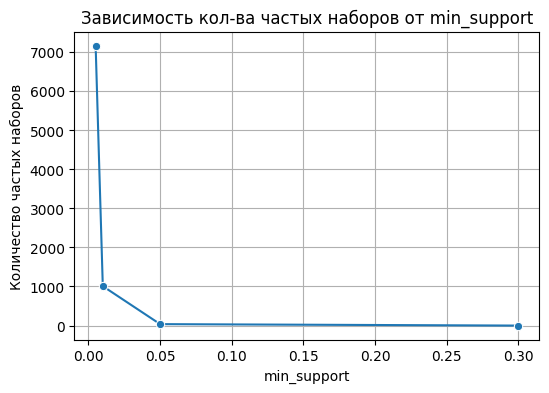

,min_support,num_itemsets,num_rules
0,0.005,7161,279
1,0.010,1008,6
2,0.300,0,0
3,0.050,37,0


In [ ]:
def run_experiments(transactions_flat, buyer_sequences):
    min_supports = [0.005, 0.01, 0.3, 0.05]
    min_confidences = [0.5, 0.7, 0.9]
    results_summary = []

    for ms in min_supports:
        freq_apriori = apriori(transactions_flat, ms)
        rules = generate_rules(freq_apriori, min_confidence=min_confidences[0],
                               min_lift=1.0, buyer_sequences=buyer_sequences)
        rules_df = pd.DataFrame(rules)
        if not rules_df.empty:
            print(f"\nmin_support={ms}, min_confidence={min_confidences[0]}")
            print(f"Найдено частых наборов: {len(freq_apriori)}")
            print(f"Найдено правил: {len(rules_df)}")
            print("Топ-10 по Lift:")
            print(rules_df.nlargest(10, 'lift')[['X', 'Y', 'lift', 'confidence']].to_string(index=False))

        results_summary.append({'min_support': ms, 'num_itemsets': len(freq_apriori), 'num_rules': len(rules_df) if not rules_df.empty else 0})

    df_res = pd.DataFrame(results_summary)
    plt.figure(figsize=(6,4))
    sns.lineplot(data=df_res, x='min_support', y='num_itemsets', marker='o')
    plt.title('Зависимость кол-ва частых наборов от min_support')
    plt.xlabel('min_support')
    plt.ylabel('Количество частых наборов')
    plt.grid(True)
    plt.show()

    return df_res

run_experiments(transactions_flat, buyer_sequences)

# Задание 5. Сравнение производительности Apriori и FP‑Growth
1. Сгенерируйте синтетические транзакционные данные с разным числом транзакций (N = 1000, 5000, 10000, 20000, 50000) и разным средним числом элементов на транзакцию (например, от 5 до 20). Для генерации можно использовать библиотеку random или специальные генераторы.
2. Для каждого размера данных измерьте время выполнения Apriori и FP-Growth при фиксированном min_support = 0.01 (или другом разумном значении). Постройте графики зависимости времени от числа транзакций.
3. Объясните полученные различия с точки зрения вычислительной сложности.


Для 1000:
Закончили apriori  за время 1.1273839473724365
Закончили FP-Growth за время 0.01877140998840332

Для 5000:
Закончили apriori  за время 8.14706039428711
Закончили FP-Growth за время 0.674558162689209

Для 10000:
Закончили apriori  за время 26.901495218276978
Закончили FP-Growth за время 3.8422422409057617

Для 20000:
Закончили apriori  за время 64.0289990901947
Закончили FP-Growth за время 18.79319953918457

Для 50000:
Закончили apriori  за время 160.20536470413208
Закончили FP-Growth за время 125.99117827415466


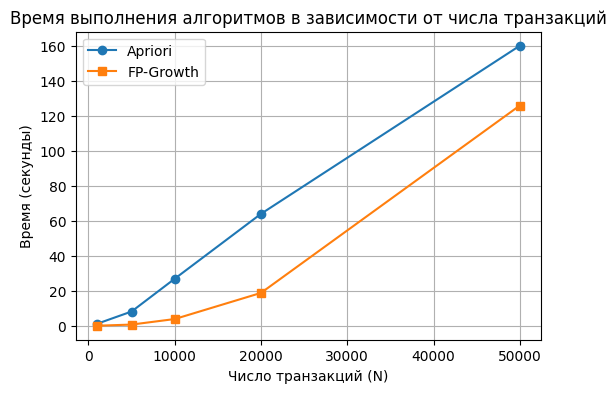

In [9]:
def benchmark():
    sizes = [1000, 5000, 10000, 20000, 50000]
    avg_len = 10
    items_pool = [f"i_{j}" for j in range(200)]

    times_apriori = []
    times_fpgrowth = []

    for n in sizes:
        # Генерация синтетики
        print(f'\nДля {n}:')
        data = [set(random.sample(items_pool, avg_len)) for _ in range(n)]

        t0 = time.time()
        apriori(data, min_support=0.01)
        times_apriori.append(time.time() - t0)
        print(f"Закончили apriori  за время {times_apriori[-1]}")

        t0 = time.time()
        fpgrowth_mine(data, min_support=0.01)
        times_fpgrowth.append(time.time() - t0)
        print(f"Закончили FP-Growth за время {times_fpgrowth[-1]}")

    plt.figure(figsize=(6,4))
    plt.plot(sizes, times_apriori, 'o-', label='Apriori')
    plt.plot(sizes, times_fpgrowth, 's-', label='FP-Growth')
    plt.title('Время выполнения алгоритмов в зависимости от числа транзакций')
    plt.xlabel('Число транзакций (N)')
    plt.ylabel('Время (секунды)')
    plt.legend()
    plt.grid(True)
    plt.show()

benchmark()

# Очевидно, что FP-Growth работает быстрее, чем Apriori.
Объясняется это тем, что алгоритм Apriori при увеличении числа кандидатов алгоритм перерывает датасет заново, тем временем как FPG делает два полноценных прохода по данным (для заголовочной таблицы и самого дерева)

# Но позже FP-Growth замедляется и почти догоняет Apriori. Почему?
(~~Вероятно~~) В тесте количетсво уникальных переменных ограничено 200 для любого числа n переменных. Это не совсем верно для реальной ситуации, поскольку при увеличении n как правило увеличивается и количество уникальных товаров. А поскольку в бенчмарке этого нет, то у Apriori практически не разростается количество кандидатов, из-за чего его прирост к времени не так существенен

# Задание 6. Визуализация ассоциативных правил
Используя matplotlib, networkx или plotly, выполните визуализацию для 20–30 наиболее интересных правил:
- Граф ассоциаций: узлы – элементы, рёбра – правила (направленные), толщина или цвет ребра отражает лифт/уверенность.
- Матрица лифтов для пар элементов (heatmap).
- Диаграмма рассеяния правил в координатах support–confidence с цветом по lift.


Задание 6: Визуализация ассоциативных правил...


/tmp/ipykernel_11188/3101723800.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


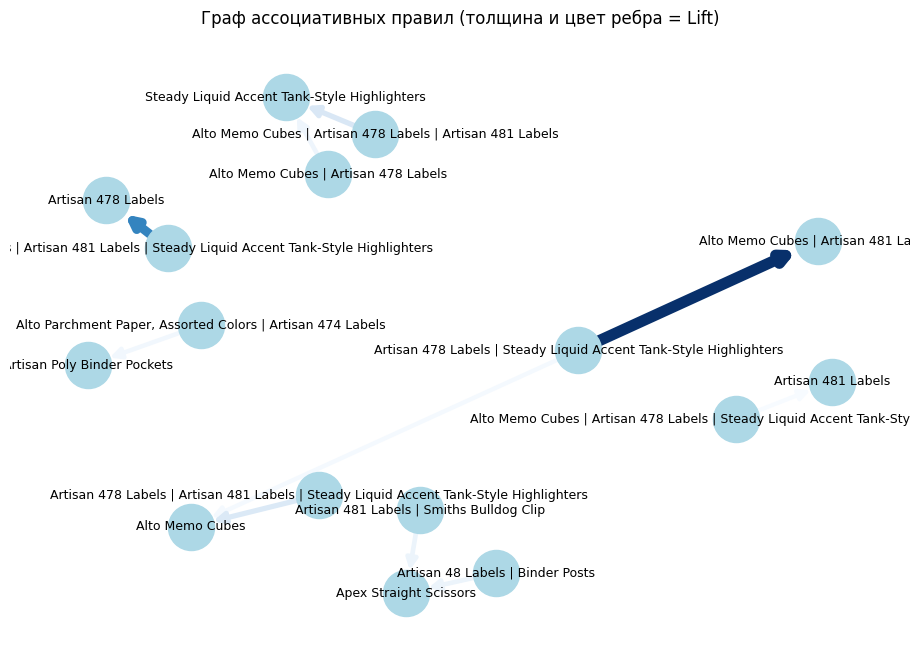

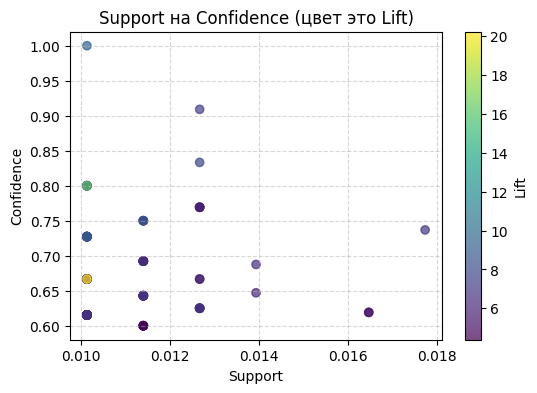

In [15]:
def visualize_rules(rules_df):
    if rules_df.empty: return

    print("\nЗадание 6: Визуализация ассоциативных правил...")

    # 1. Граф ассоциаций
    G = nx.DiGraph()
    top_rules = rules_df.nlargest(min(10, len(rules_df)), 'lift')
    for _, row in top_rules.iterrows():
        ant = " | ".join(map(str, row['X']))
        con = " | ".join(map(str, row['Y']))
        G.add_edge(ant, con, weight=row['lift'])

    plt.figure(figsize=(9, 6))
    pos = nx.spring_layout(G, k=0.9, seed=42)
    weights = [G[u][v]['weight'] for u, v in G.edges()]

    nx.draw(G, pos, with_labels=True, node_color='lightblue',
            edge_cmap=plt.cm.Blues, width=[max(1.5, w * 0.4) for w in weights],
            node_size=1100, font_size=9, arrows=True, arrowsize=16,
            edge_color=weights)

    plt.title("Граф ассоциативных правил (толщина и цвет ребра = Lift)", pad=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 2. Scatter plot Support-Confidence
    plt.figure(figsize=(6,4))
    scatter = plt.scatter(rules_df['support'], rules_df['confidence'],
                          c=rules_df['lift'], cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label='Lift')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Support на Confidence (цвет это Lift)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


freq = apriori(transactions_flat, min_support=0.01)
rules = generate_rules(freq, min_confidence=0.6, min_lift=1.0, buyer_sequences=None)
visualize_rules(pd.DataFrame(rules))


# Задание 7. Интерпретация результатов
На основе найденных правил сделайте выводы, значимые для предметной области. Например, для розничных данных – какие товары покупают вместе, какие правила могут быть использованы для рекомендаций или перекрестных продаж. Обоснуйте, почему некоторые правила (даже с высоким lift) могут быть бесполезными (тривиальные, очевидные или связанные с очень редкими товарами).

# Во-первых: Товары представляют из себя канцелярские принадлежности узкой специализации

## Поскольку все правило показывают низкую поддержку (0.010 – 0.018), а это означает, что данные товары не являются массовыми (обычная бумага или ручки); Высокий Confidence (от 0.60) -> несмотря на редкость покупок, если покупатель берет один из этих товаров, вероятность покупки связанного товара высока

 Так как в граф толщина ребра = Lift, то можно выделить несколько устойчивых связей:

## 1. Правило: (Artisan 478 Labels | Artisan 481 Labels) -> (Alto Memo Cubes)
Или по русски:
(Этикетки 478|Этикетки 481) -> (квадратные стикеры для заметок)

Покупатели, приобретающие разные виды этикеток (Labels 478 и 481), часто докупают стикеры или кубики для заметок (Memo Cubes). Вероятно, это разные размеры или типы этикеток для одной системы архивации.

## 2. (Этикетки 478 | Жидкие маркеры-текстовыделители) -> (Квадратные стикеры для заметок | Этикетки 481)

Люди часто используют текстовыделители этикетках и стикерах. При чём довольно часто покупают их вместе. Логично располагать их рядом для совместной продажи

## 3. и сразу 4. (Этикетки 48 | зажим для бумаги) -> (ножницы) и (Этикетки 481 | булавки или скрепки) -> (ножницы)

Имеет смысл предлагать покупателю ножницы, если он собирается крепить заметки

# Почему некоторые правила могут быть бесполезными?
Несмотря на высокие Lift и Confidence, некоторые правила могут не принести пользы потому, что поддержка < 0.02 (правило срабатывает крайне редко);

<br>

!ВАЖНО! В названиях "Этикетки N" число N скорее всего означает размер или зашифрованный формат